In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
df_2024_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal= ',')
df_2024_2 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2024.02.csv', sep=';', decimal= ',')
df_2025_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal= ',')
df_2025_2 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.02.csv', sep=';', decimal= ',')

C:\Users\carlos.orodrigues\AppData\Local\Temp\ipykernel_11104\1461245115.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv ('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal= ',')


In [18]:
df = pd.concat([df_2024_1, df_2024_2, df_2025_1, df_2025_2], ignore_index=True)
print (df.shape) 
display (df.head())

(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1712267 entries, 0 to 1712266
Data columns (total 16 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Regiao - Sigla     str    
 1   Estado - Sigla     str    
 2   Municipio          str    
 3   Revenda            str    
 4   CNPJ da Revenda    object 
 5   Nome da Rua        str    
 6   Numero Rua         str    
 7   Complemento        str    
 8   Bairro             str    
 9   Cep                str    
 10  Produto            str    
 11  Data da Coleta     str    
 12  Valor de Venda     float64
 13  Valor de Compra    float64
 14  Unidade de Medida  str    
 15  Bandeira           str    
dtypes: float64(2), object(1), str(13)
memory usage: 209.0+ MB


In [20]:
print(df.columns)

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='str')


In [21]:
TESTE = df ['Municipio'].value_counts().reset_index() #para verificar o que há dentro da coluna, nesse caso produto
TESTE

,Municipio,count
0,SAO PAULO,80021
1,RIO DE JANEIRO,34045
2,FORTALEZA,18010
3,BRASILIA,16631
4,CURITIBA,16500
...,...,...
456,CAMETA,223
457,SAPUCAIA,204
458,VERA CRUZ,63
459,GAVIAO,55


In [22]:
df.tail(3)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
1712264,NE,BA,ILHEUS,BATISTA COMERCIO DE COMBUSTIVEIS E LUBRIFICANT...,28562491000183,AVENIDA FERROVIARIA,S/N,KM 05 RODOVIA ILHEUS,IGUAPE,45658-340,GNV,31/12/2025,4.73,NaN,R$ / m3,BRANCA
1712265,SE,SP,JACAREI,AUTO POSTO BRANCO DE CASTELO LTDA,68912864000385,AVENIDA SIQUEIRA CAMPOS,641,NaN,CENTRO,12308-190,GNV,31/12/2025,3.99,NaN,R$ / m3,VIBRA
1712266,S,RS,LAJEADO,SIM REDE DE POSTOS LTDA,7473735018714,RODOVIA ERS-130,2285,KM 72.8,SANTO ANDRE,95912-000,GNV,31/12/2025,5.65,NaN,R$ / m3,CHARRUA


In [23]:
#1. filtro com loc para achar somente o que preciso, no caso só gasolina no estado do RJ
df_gasolina = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]
df_gasolina


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
122,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
130,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,RAIZEN
131,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO SAO LUCAS DE CAMPOS LTDA,04.718.173/0001-09,"RODOVIA BR-101 KM 80,5",S/N,NaN,IBITIOCA,28120-000,GASOLINA,01/01/2024,5.89,NaN,R$ / litro,RAIZEN
133,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
136,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,GASOLINA,01/01/2024,5.79,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1622777,SE,RJ,NOVA FRIBURGO,F.MURY DESIGN PROPAGANDA E PUBLICIDADE LTDA,7707130000299,ESTRADA FRIBURGO AMPARO,15604,LP N 0130/2018 LP N 0440/2019,CHACARA PARAISO,28605-520,GASOLINA,30/12/2025,6.69,NaN,R$ / litro,VIBRA
1622806,SE,RJ,MARICA,POSTO NOVO RECREIO LTDA,24787241000352,AVENIDA MAYSA,12656,LOTE 4 A QUADRA 24,BARRA DE MARICÁ,24915-400,GASOLINA,30/12/2025,6.39,NaN,R$ / litro,BRANCA
1622972,SE,RJ,ANGRA DOS REIS,AUTO POSTO ENCRUZO DA ENSEADA LTDA,3340868000129,RUA PREFEITO JOAO GREGORIO GALINDO,S/N,LOTE 02,CAMPO BELO (CUNHAMBEBE),23932-400,GASOLINA,31/12/2025,6.69,NaN,R$ / litro,IPIRANGA
1622973,SE,RJ,TRES RIOS,AUTO LUBRIFICADORA TRIRRIENSE LTDA,28863579000135,RUA BARAO DE ENTRE RIOS,401,NaN,CENTRO,25802-315,GASOLINA,31/12/2025,6.89,NaN,R$ / litro,IPIRANGA


In [24]:
#outra forma de filtro com loc, mais usado quando preciso de mais elementos dentro do filtro
df_prod = ['GASOLINA']#cria a lista

df_rj = df.loc[df['Produto'].isin(df_prod) & (df['Estado - Sigla'] == 'RJ')]#faz o isin pra puxar o que há dentro da lista que está como variável df_prod
df_rj

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
122,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
130,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,RAIZEN
131,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO SAO LUCAS DE CAMPOS LTDA,04.718.173/0001-09,"RODOVIA BR-101 KM 80,5",S/N,NaN,IBITIOCA,28120-000,GASOLINA,01/01/2024,5.89,NaN,R$ / litro,RAIZEN
133,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
136,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,GASOLINA,01/01/2024,5.79,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1622777,SE,RJ,NOVA FRIBURGO,F.MURY DESIGN PROPAGANDA E PUBLICIDADE LTDA,7707130000299,ESTRADA FRIBURGO AMPARO,15604,LP N 0130/2018 LP N 0440/2019,CHACARA PARAISO,28605-520,GASOLINA,30/12/2025,6.69,NaN,R$ / litro,VIBRA
1622806,SE,RJ,MARICA,POSTO NOVO RECREIO LTDA,24787241000352,AVENIDA MAYSA,12656,LOTE 4 A QUADRA 24,BARRA DE MARICÁ,24915-400,GASOLINA,30/12/2025,6.39,NaN,R$ / litro,BRANCA
1622972,SE,RJ,ANGRA DOS REIS,AUTO POSTO ENCRUZO DA ENSEADA LTDA,3340868000129,RUA PREFEITO JOAO GREGORIO GALINDO,S/N,LOTE 02,CAMPO BELO (CUNHAMBEBE),23932-400,GASOLINA,31/12/2025,6.69,NaN,R$ / litro,IPIRANGA
1622973,SE,RJ,TRES RIOS,AUTO LUBRIFICADORA TRIRRIENSE LTDA,28863579000135,RUA BARAO DE ENTRE RIOS,401,NaN,CENTRO,25802-315,GASOLINA,31/12/2025,6.89,NaN,R$ / litro,IPIRANGA


In [25]:
#2 média de preço dos municípios do RJ
df_gasolina_comum_rj = df_gasolina.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_comum_rj

,Municipio,Valor de Venda
29,TRES RIOS,6.591634
0,ANGRA DOS REIS,6.521620
18,PETROPOLIS,6.479639
2,BARRA DO PIRAI,6.375640
11,MACAE,6.364828
16,NOVA FRIBURGO,6.357044
10,ITAPERUNA,6.352013
6,CAMPOS DOS GOYTACAZES,6.338306
5,CABO FRIO,6.322089
23,SAO FRANCISCO DE ITABAPOANA,6.214804


In [26]:
#coluna 'Data da Coleta' está em string, aqui converto para float, para usar no gráfico, fazendo dados de data da coleta assumir questão temporal
df_gasolina['Data da Coleta'] = pd.to_datetime(df_gasolina['Data da Coleta'], dayfirst=True)


In [27]:

df_gasosa_tempo = df_gasolina.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Data da Coleta')
df_gasosa_tempo

,Data da Coleta,Valor de Venda
0,2024-01-01,5.674773
1,2024-01-02,5.638221
2,2024-01-03,5.769762
3,2024-01-04,5.632800
4,2024-01-05,5.396000
...,...,...
472,2025-12-25,6.790000
473,2025-12-26,6.277838
474,2025-12-29,6.095144
475,2025-12-30,6.148113


<function matplotlib.pyplot.show(close=None, block=None)>

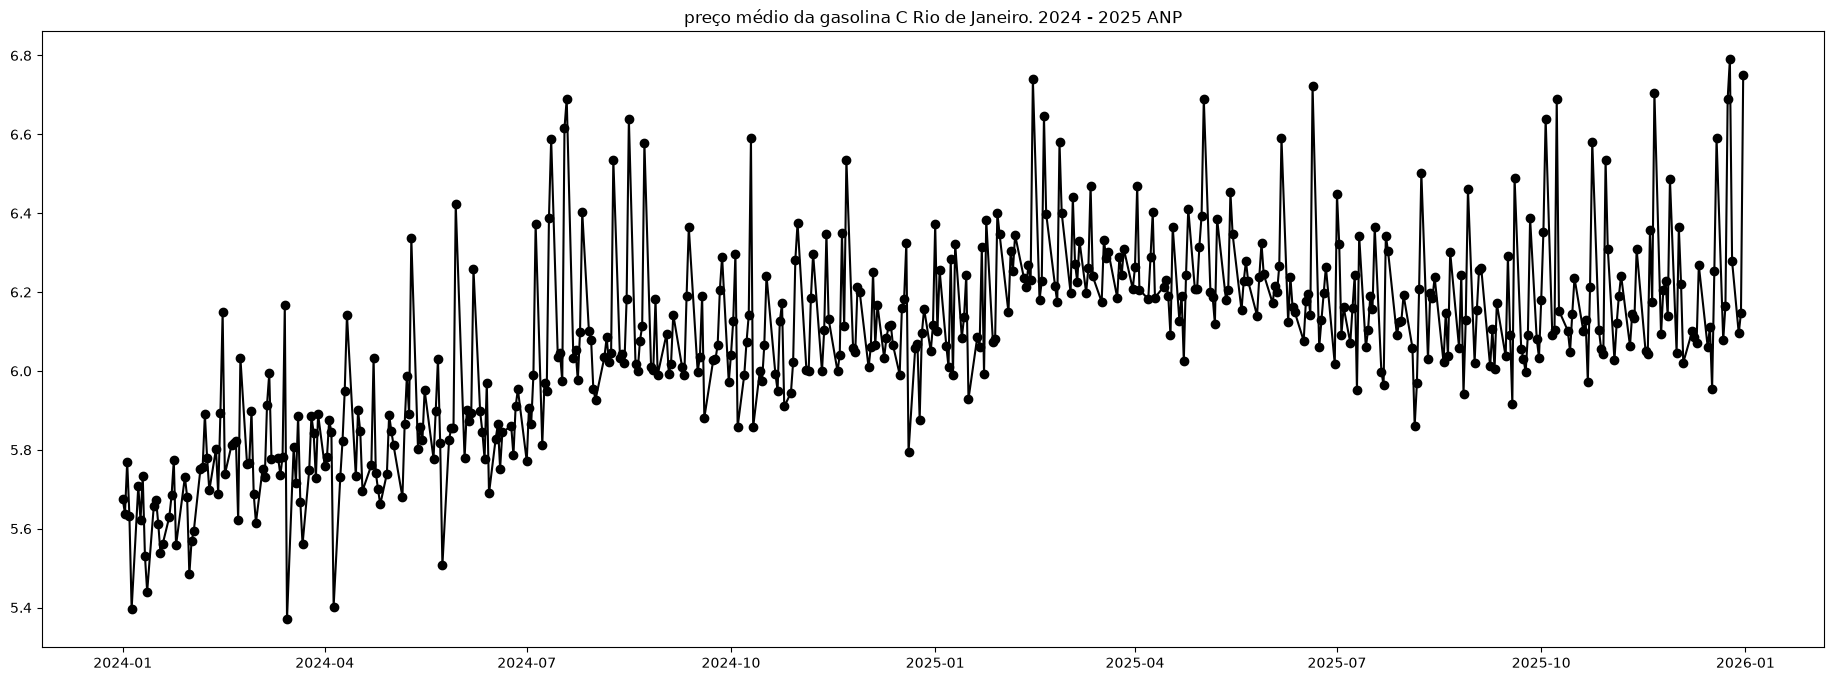

In [28]:
plt.figure(figsize=(23,8))
plt.plot(df_gasosa_tempo['Data da Coleta'], df_gasosa_tempo['Valor de Venda'], marker = 'o', color='black')
plt.title('preço médio da gasolina C Rio de Janeiro. 2024 - 2025 ANP')
plt.show

In [29]:
df_gasolina_comum_rj_posto = df_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_comum_rj_posto

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000
776,POSTO SATURNO FRIBURGO LTDA,6.824444
1,A C TRANCOZO M B COMBUSTIVEIS LTDA,6.742157
304,COMERCIO DE PETROLEO E DERIVADOS COND DO RIO N...,6.713529
...,...,...
668,POSTO FLAMAREDI EIRELI,5.282000
571,POSTO DE GASOLINA JARDIM SULACAP LTDA,5.226364
569,POSTO DE GASOLINA JAGUAR DO ANIL LTDA,5.156667
567,POSTO DE GASOLINA ITAJUBA LTDA,5.090000


In [30]:
array_gas_comum_rj = np.array(df_gasolina_comum_rj_posto['Valor de Venda'])
array_gas_comum_rj

array([7.75067416, 7.415     , 6.82444444, 6.74215686, 6.71352941,
       6.71295082, 6.70469136, 6.69666667, 6.69576923, 6.69      ,
       6.69      , 6.68906667, 6.67028169, 6.67      , 6.665     ,
       6.66227273, 6.656     , 6.61461538, 6.60436893, 6.59756757,
       6.576     , 6.57444444, 6.56375   , 6.56142857, 6.55833333,
       6.55712329, 6.54869565, 6.54581395, 6.54531915, 6.54      ,
       6.54      , 6.54      , 6.53769231, 6.53672131, 6.53590164,
       6.53084507, 6.53038462, 6.52978495, 6.52878788, 6.52818182,
       6.5257971 , 6.52333333, 6.52125   , 6.51857143, 6.5145283 ,
       6.51307692, 6.50411765, 6.49882353, 6.49      , 6.49      ,
       6.49      , 6.49      , 6.49      , 6.49      , 6.49      ,
       6.49      , 6.49      , 6.48046512, 6.48      , 6.4797561 ,
       6.47571429, 6.47095238, 6.466     , 6.46333333, 6.46105263,
       6.45722222, 6.45470588, 6.45410256, 6.45216216, 6.45027778,
       6.44931034, 6.44584615, 6.44325581, 6.443125  , 6.44081

In [31]:
media = np.mean(array_gas_comum_rj)
mediana = np.median(array_gas_comum_rj)
q1 = np.percentile(array_gas_comum_rj, 25)
q3 = np.percentile(array_gas_comum_rj,75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
distancia = (media - mediana) / mediana

print (f'Média {media}')
print (f'Mediana {mediana}')
print (f'Distancia {distancia:.2%}')
print (f'Q1 {q1}')
print (f'Q3 {q3}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')


Média 5.947818265606212
Mediana 5.9136419461502125
Distancia 0.58%
Q1 5.692154135338346
Q3 6.19
Limite Superior 6.936768796992482
Limite Inferior 4.945385338345865


In [32]:
outlier_sup_preco = df_gasolina_comum_rj_posto.loc[df_gasolina_comum_rj_posto['Valor de Venda'] > limite_superior]

outlier_sup_preco

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000


In [33]:
outlier_inf_preco = df_gasolina_comum_rj_posto.loc[df_gasolina_comum_rj_posto['Valor de Venda'] < limite_inferior]

outlier_inf_preco

,Revenda,Valor de Venda


In [34]:
df_est = ['RJ','SP']
df_eta = df.loc[df['Estado - Sigla'].isin(df_est) & (df['Produto'] == 'ETANOL')]
df_eta

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
125,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,ETANOL,01/01/2024,4.39,NaN,R$ / litro,VIBRA
128,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,ETANOL,01/01/2024,4.29,NaN,R$ / litro,RAIZEN
135,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,ETANOL,01/01/2024,4.29,NaN,R$ / litro,VIBRA
138,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,ETANOL,01/01/2024,4.09,NaN,R$ / litro,BRANCA
143,SE,RJ,CAMPOS DOS GOYTACAZES,CAMPOS GAROUPA LTDA.,03.581.079/0002-60,AVENIDA 15 DE NOVEMBRO,353,NaN,CENTRO,28030-002,ETANOL,01/01/2024,4.17,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521773,SE,SP,ARARAQUARA,AUTO POSTO 22 DE AGOSTO ARARAQUARA LTDA,35826432000130,AVENIDA VINTE E DOIS DE AGOSTO,479,NaN,VILA XAVIER,14801-970,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521783,SE,SP,ARARAQUARA,BIO SEVEN POSTO DE COMBUSTIVEIS E LUBRIFICANTE...,40270089000120,AVENIDA ANTONIO GOMES DA SILVA,65,NaN,JARDIM SAO FRANCISCO,14806-657,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521786,SE,SP,BIRIGUI,AUTO POSTO MAYTA LTDA,31206891000160,RUA DOUTOR ARTHUR CORDEIRO,620,NaN,PATRIMONIO SILVARES,16201-003,ETANOL,31/12/2025,4.09,NaN,R$ / litro,VIBRA
1521789,SE,SP,VARZEA PAULISTA,MALU SANTOS COMERCIO DE COMBUSTIVEIS LTDA,41256798000114,RUA SOROCABA,605,NaN,JARDIM PAULISTA,13222-005,ETANOL,31/12/2025,4.29,NaN,R$ / litro,BRANCA


In [35]:
df_RJ_etanol = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'ETANOL')]
df_RJ_etanol

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
125,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,ETANOL,01/01/2024,4.39,NaN,R$ / litro,VIBRA
128,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,ETANOL,01/01/2024,4.29,NaN,R$ / litro,RAIZEN
135,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,ETANOL,01/01/2024,4.29,NaN,R$ / litro,VIBRA
138,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,ETANOL,01/01/2024,4.09,NaN,R$ / litro,BRANCA
143,SE,RJ,CAMPOS DOS GOYTACAZES,CAMPOS GAROUPA LTDA.,03.581.079/0002-60,AVENIDA 15 DE NOVEMBRO,353,NaN,CENTRO,28030-002,ETANOL,01/01/2024,4.17,NaN,R$ / litro,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521258,SE,RJ,NITEROI,JUTURNAIBA COMERCIO DE COMBUSTIVEIS LTDA.,9087994000108,ESTRADA FRANCISCO DA CRUZ NUNES,9163,NaN,ITAIPU,24340-000,ETANOL,30/12/2025,4.89,NaN,R$ / litro,IPIRANGA
1521260,SE,RJ,NOVA FRIBURGO,F.MURY DESIGN PROPAGANDA E PUBLICIDADE LTDA,7707130000299,ESTRADA FRIBURGO AMPARO,15604,LP N 0130/2018 LP N 0440/2019,CHACARA PARAISO,28605-520,ETANOL,30/12/2025,5.19,NaN,R$ / litro,VIBRA
1521282,SE,RJ,MARICA,POSTO NOVO RECREIO LTDA,24787241000352,AVENIDA MAYSA,12656,LOTE 4 A QUADRA 24,BARRA DE MARICÁ,24915-400,ETANOL,30/12/2025,4.69,NaN,R$ / litro,BRANCA
1521428,SE,RJ,TRES RIOS,AUTO LUBRIFICADORA TRIRRIENSE LTDA,28863579000135,RUA BARAO DE ENTRE RIOS,401,NaN,CENTRO,25802-315,ETANOL,31/12/2025,5.39,NaN,R$ / litro,IPIRANGA


In [36]:
df_etanol_rj = df_RJ_etanol.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_rj

,Municipio,Valor de Venda
29,TRES RIOS,5.128235
18,PETROPOLIS,5.062155
0,ANGRA DOS REIS,5.005747
11,MACAE,4.773617
2,BARRA DO PIRAI,4.752474
5,CABO FRIO,4.734201
31,VOLTA REDONDA,4.674676
3,BARRA MANSA,4.562342
6,CAMPOS DOS GOYTACAZES,4.557049
30,VALENCA,4.535458


In [37]:
array_etanol_rj = np.array(df_etanol_rj['Valor de Venda'])
array_etanol_rj

array([5.12823529, 5.06215457, 5.00574689, 4.77361702, 4.75247423,
       4.73420097, 4.67467611, 4.56234197, 4.55704902, 4.53545775,
       4.50306995, 4.49606061, 4.48051331, 4.4788755 , 4.46498208,
       4.41774019, 4.39675936, 4.34302111, 4.3406414 , 4.32297872,
       4.31151693, 4.29254464, 4.29171223, 4.27808239, 4.27635229,
       4.27281899, 4.24752306, 4.23475019, 4.19867018, 4.04583851,
       3.98933333, 3.81698225])

In [38]:
media_rj = np.mean(array_etanol_rj)
mediana_rj = np.median(array_etanol_rj)
q1_rj = np.percentile(array_etanol_rj, 25)
q3_rj = np.percentile(array_etanol_rj,75)
iqr = q3_rj - q1_rj
limite_superior_rj = q3_rj + (1.5 * iqr)
limite_inferior_rj = q1_rj - (1.5 * iqr)
distancia = (media_rj - mediana_rj) / mediana_rj

print (f'Média {media_rj}')
print (f'Mediana {mediana_rj}')
print (f'Distancia {distancia:.2%}')
print (f'Q1 {q1_rj}')
print (f'Q3 {q3_rj}')
print(f'Limite Superior {limite_superior_rj}')
print(f'Limite Inferior {limite_inferior_rj}')

Média 4.446460031915704
Mediana 4.407249773866983
Distancia 0.89%
Q1 4.27764986189478
Q3 4.558372256933862
Limite Superior 4.979455849492485
Limite Inferior 3.8565662693361564


In [39]:
df_SP_etanol = df.loc[(df['Estado - Sigla'] == 'SP') & (df['Produto'] == 'ETANOL')]
df_SP_etanol

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
285,SE,SP,POA,PORTAL DE POA AUTO POSTO LTDA,04.576.763/0001-36,RODOVIA JOAO AFONSO DE SOUZA CASTELLANO,1890,NaN,VILA JAU,08559-000,ETANOL,01/01/2024,3.12,NaN,R$ / litro,BRANCA
289,SE,SP,POA,AUTO POSTO FLOR DE CALMON LTDA,60.176.211/0001-01,AVENIDA BRASIL,1170,NaN,CALMON VIANA,08560-010,ETANOL,01/01/2024,3.39,NaN,R$ / litro,BRANCA
291,SE,SP,POA,AUTO POSTO ESTÂNCIA HIDROMINERAL DE POÁ LTDA.,03.017.060/0001-05,AVENIDA PREFEITO FRANCISCO RODRIGUES FILHO,300,NaN,CENTRO,08561-200,ETANOL,01/01/2024,3.19,NaN,R$ / litro,BRANCA
295,SE,SP,POA,CENTRO AUTOMOTIVO REAL LESTE LTDA,01.456.575/0001-86,AVENIDA LUCAS NOGUEIRA GARCEZ,677,NaN,V STA MARIA,08563-100,ETANOL,01/01/2024,3.36,NaN,R$ / litro,IPIRANGA
299,SE,SP,SAO JOSE DO RIO PRETO,POSTO ITAMARATI - ANANDA LTDA.,03.473.355/0001-96,"RUA PEDRO AMARAL,",3581,NaN,VILA ERCILIA,15014-000,ETANOL,01/01/2024,3.09,NaN,R$ / litro,VIBRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521773,SE,SP,ARARAQUARA,AUTO POSTO 22 DE AGOSTO ARARAQUARA LTDA,35826432000130,AVENIDA VINTE E DOIS DE AGOSTO,479,NaN,VILA XAVIER,14801-970,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521783,SE,SP,ARARAQUARA,BIO SEVEN POSTO DE COMBUSTIVEIS E LUBRIFICANTE...,40270089000120,AVENIDA ANTONIO GOMES DA SILVA,65,NaN,JARDIM SAO FRANCISCO,14806-657,ETANOL,31/12/2025,3.97,NaN,R$ / litro,BRANCA
1521786,SE,SP,BIRIGUI,AUTO POSTO MAYTA LTDA,31206891000160,RUA DOUTOR ARTHUR CORDEIRO,620,NaN,PATRIMONIO SILVARES,16201-003,ETANOL,31/12/2025,4.09,NaN,R$ / litro,VIBRA
1521789,SE,SP,VARZEA PAULISTA,MALU SANTOS COMERCIO DE COMBUSTIVEIS LTDA,41256798000114,RUA SOROCABA,605,NaN,JARDIM PAULISTA,13222-005,ETANOL,31/12/2025,4.29,NaN,R$ / litro,BRANCA


In [40]:
df_etanol_sp = df_SP_etanol.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_etanol_sp

,Municipio,Valor de Venda
10,BARUERI,4.437937
24,CUBATAO,4.394575
31,GUARUJA,4.329950
99,TATUI,4.270063
18,CARAGUATATUBA,4.192511
...,...,...
26,DRACENA,3.420116
92,SAO ROQUE,3.396087
81,SANTA BARBARA D'OESTE,3.373045
58,MIRASSOL,3.194895


In [41]:
array_etanol_sp = np.array(df_etanol_sp['Valor de Venda'])
array_etanol_sp

array([4.43793736, 4.39457539, 4.32994995, 4.27006329, 4.19251078,
       4.13809341, 4.13762121, 4.13335784, 4.10606965, 4.09150376,
       4.08727707, 4.07923642, 4.06384106, 4.05533679, 4.05289406,
       4.04768734, 4.03909661, 4.03427835, 4.0325599 , 4.01778173,
       4.0087282 , 4.00113139, 3.97967153, 3.97912214, 3.9770068 ,
       3.97584924, 3.97145215, 3.96539948, 3.95016667, 3.94144893,
       3.93757576, 3.93630102, 3.93519792, 3.9327451 , 3.93176495,
       3.93169856, 3.93067174, 3.92514573, 3.92412488, 3.92241679,
       3.92150358, 3.918     , 3.91302732, 3.89768601, 3.89603034,
       3.89555725, 3.89414213, 3.89372861, 3.89318277, 3.8921308 ,
       3.88824161, 3.88794012, 3.88666667, 3.88350835, 3.87573813,
       3.87426966, 3.87213053, 3.86629247, 3.86416327, 3.86115146,
       3.84697892, 3.83947991, 3.83169811, 3.8310395 , 3.83090493,
       3.82717195, 3.8256797 , 3.82421277, 3.82213613, 3.82088623,
       3.80309681, 3.80078189, 3.79258152, 3.78767695, 3.78412

In [42]:
media_sp = np.mean(array_etanol_sp)
mediana_sp = np.median(array_etanol_sp)
q1_sp = np.percentile(array_etanol_sp, 25)
q3_sp = np.percentile(array_etanol_sp,75)
iqr = q3_sp - q1_sp
limite_superior_sp = q3_sp + (1.5 * iqr)
limite_inferior_sp = q1_sp - (1.5 * iqr)
distancia_sp = (media_sp - mediana_sp) / mediana_sp

print (f'Média SP {media_sp}')
print (f'Mediana SP {mediana_sp}')
print (f'Distancia {distancia_sp:.2%}')
print (f'Q1 {q1_sp}')
print (f'Q3 {q3_sp}')
print(f'Limite Superior {limite_superior_sp}')
print(f'Limite Inferior {limite_inferior_sp}')

Média SP 3.857237583625291
Mediana SP 3.8796232395121337
Distancia -0.58%
Q1 3.7518841150359172
Q3 3.9669126446587217
Limite Superior 4.2894554390929285
Limite Inferior 3.4293413206017105


In [43]:

print (f'Média do etanol RJ {media_rj}\nMédia do etanol SP {media_sp}')

print(f'Maior preço RJ\n {df_etanol_rj.max()}')
print(f'Menor preço RJ\n {df_etanol_rj.min()}')

print(f'Maior preço SP\n {df_etanol_sp.max()}')
print(f'Menor preço SP\n {df_etanol_sp.min()}')


Média do etanol RJ 4.446460031915704
Média do etanol SP 3.857237583625291
Maior preço RJ
 Municipio         VOLTA REDONDA
Valor de Venda         5.128235
dtype: object
Menor preço RJ
 Municipio         ANGRA DOS REIS
Valor de Venda          3.816982
dtype: object
Maior preço SP
 Municipio         VOTUPORANGA
Valor de Venda       4.437937
dtype: object
Menor preço SP
 Municipio         ADAMANTINA
Valor de Venda      3.182949
dtype: object


In [44]:
outlier_sup_preco_rj_eta = df_etanol_rj.loc[df_etanol_rj['Valor de Venda'] > limite_superior_rj]

outlier_sup_preco_rj_eta

,Municipio,Valor de Venda
29,TRES RIOS,5.128235
18,PETROPOLIS,5.062155
0,ANGRA DOS REIS,5.005747


In [45]:
outlier_inf_preco_rj_eta = df_etanol_rj.loc[df_etanol_rj['Valor de Venda'] < limite_inferior_rj]

outlier_inf_preco_rj_eta

,Municipio,Valor de Venda
28,TERESOPOLIS,3.816982


In [46]:
outlier_sup_preco_sp_eta = df_etanol_sp.loc[df_etanol_sp['Valor de Venda'] > limite_superior_sp]

outlier_sup_preco_sp_eta

,Municipio,Valor de Venda
10,BARUERI,4.437937
24,CUBATAO,4.394575
31,GUARUJA,4.329950


In [47]:
outlier_inf_preco_sp_eta = df_etanol_sp.loc[df_etanol_sp['Valor de Venda'] < limite_inferior_sp]

outlier_inf_preco_sp_eta

,Municipio,Valor de Venda
26,DRACENA,3.420116
92,SAO ROQUE,3.396087
81,SANTA BARBARA D'OESTE,3.373045
58,MIRASSOL,3.194895
76,PRESIDENTE VENCESLAU,3.182949


In [ ]:
df_gasosa = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]
df_gasosa

In [ ]:
df_gasolina_bairro_rj = df_gasosa.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_gasolina_bairro_rj

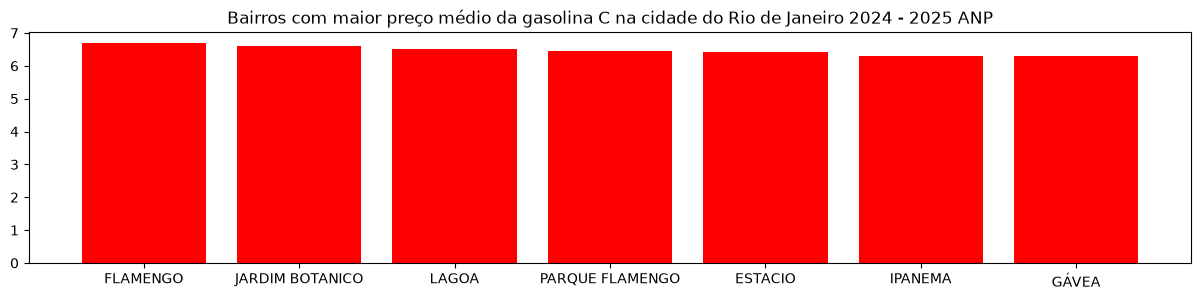

In [89]:
plt.figure(figsize=(15,3))
plt.bar(df_gasolina_bairro_rj.head(7)['Bairro'], df_gasolina_bairro_rj.head(7)['Valor de Venda'], color='red')
plt.title('Bairros com maior preço médio da gasolina C na cidade do Rio de Janeiro 2024 - 2025 ANP')
plt.show()

In [90]:
df_gasolina_bairro_rj = df_gasosa.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda')
df_gasolina_bairro_rj

,Bairro,Valor de Venda
3,ANIL,5.156667
43,JARDIM SULACAP,5.226364
49,MARIA DA GRACA,5.290000
37,JACARE,5.310000
50,MEIER,5.340000
...,...,...
21,ESTACIO,6.416882
55,PARQUE FLAMENGO,6.454706
44,LAGOA,6.505385
41,JARDIM BOTANICO,6.614615


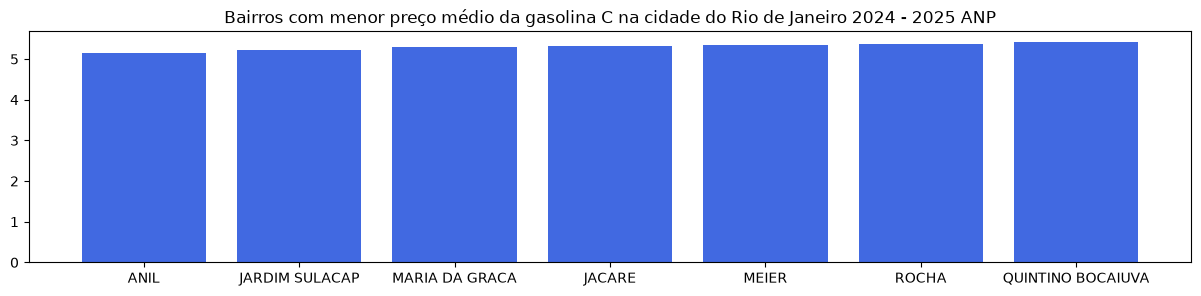

In [91]:
plt.figure(figsize=(15,3))
plt.bar(df_gasolina_bairro_rj.head(7)['Bairro'], df_gasolina_bairro_rj.head(7)['Valor de Venda'], color='#4169E1')
plt.title('Bairros com menor preço médio da gasolina C na cidade do Rio de Janeiro 2024 - 2025 ANP')
plt.show()

In [ ]:
array_bairro = np.array(df_gasolina_bairro_rj['Valor de Venda'])
array_bairro



In [53]:
minimo = np.min(array_bairro)
maximo = np.max(array_bairro)
amplitude = maximo - minimo
media_br = np.mean (array_bairro)
mediana_br = np.median (array_bairro)
q1_br = np.percentile(array_bairro, 25)
q3_br = np.percentile(array_bairro,75)
iqr_br = q3_br - q1_br
limite_superior_br = q3_br + (1.5 * iqr_br)
limite_inferior_br = q1_br - (1.5 * iqr_br)
distancia_br = (media_br - mediana_br) / mediana_br

print (f'Mínimo {minimo}')
print (f'Máximo {maximo}')
print (f'Amplitude {amplitude}')
print (f'Média {media_br}')
print (f'Mediana {mediana_br}')
print (f'Distancia {distancia_br:.2%}')
print (f'Q1 {q1_br}')
print (f'Q3 {q3_br}')
print(f'Limite Superior {limite_superior_br}')
print(f'Limite Inferior {limite_inferior_br}')

Mínimo 5.156666666666666
Máximo 6.696666666666667
Amplitude 1.540000000000001
Média 5.854678797322661
Mediana 5.8434
Distancia 0.19%
Q1 5.640000000000001
Q3 6.060588235294118
Limite Superior 6.691470588235293
Limite Inferior 5.009117647058825


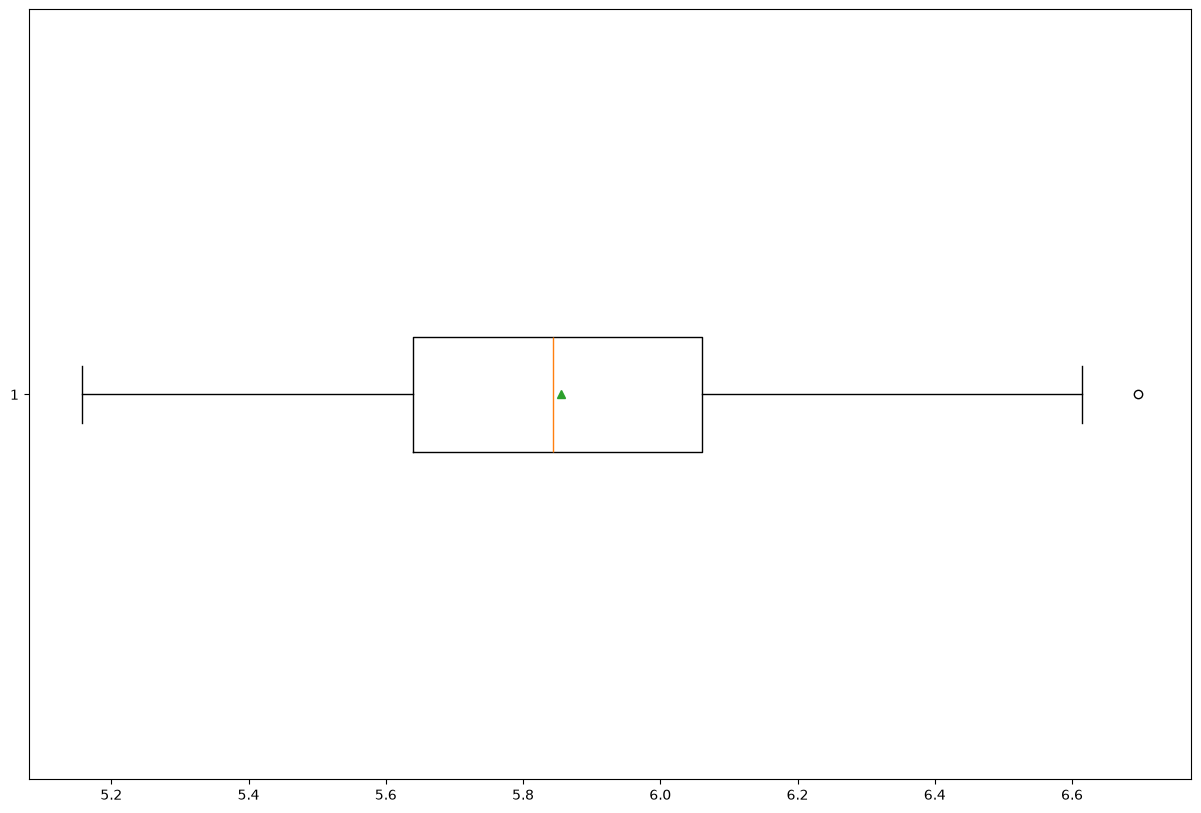

In [54]:
plt.figure(figsize=(15,10))
plt.boxplot(array_bairro, orientation='horizontal', showmeans=True)
plt.show()

In [55]:
outlier_sup_bairro = df_gasolina_bairro_rj.loc[df_gasolina_bairro_rj['Valor de Venda'] > limite_superior_br]
outlier_sup_bairro

,Bairro,Valor de Venda
23,FLAMENGO,6.696667


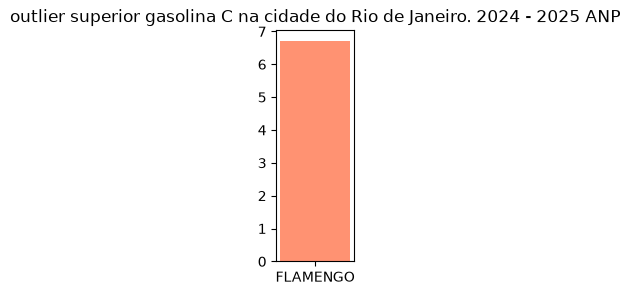

In [56]:
plt.figure(figsize=(1,3))
plt.bar(outlier_sup_bairro['Bairro'], outlier_sup_bairro['Valor de Venda'], color='#FF9272')
plt.title('outlier superior gasolina C na cidade do Rio de Janeiro. 2024 - 2025 ANP')
plt.show()



In [57]:
outlier_inf_bairro = df_gasolina_bairro_rj.loc[df_gasolina_bairro_rj['Valor de Venda'] < limite_inferior_br]
outlier_inf_bairro

,Bairro,Valor de Venda


In [ ]:
df_gasosa_fla = df.loc[(df['Bairro'] == 'FLAMENGO') & (df['Produto'] == 'GASOLINA')]
df_gasosa_fla

In [59]:
df_gasosa_fla['Data da Coleta'] = pd.to_datetime(df_gasosa_fla['Data da Coleta'], dayfirst=True)

In [ ]:
df_gasosa_flamengo = df_gasosa_fla.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Data da Coleta')
df_gasosa_flamengo

<function matplotlib.pyplot.show(close=None, block=None)>

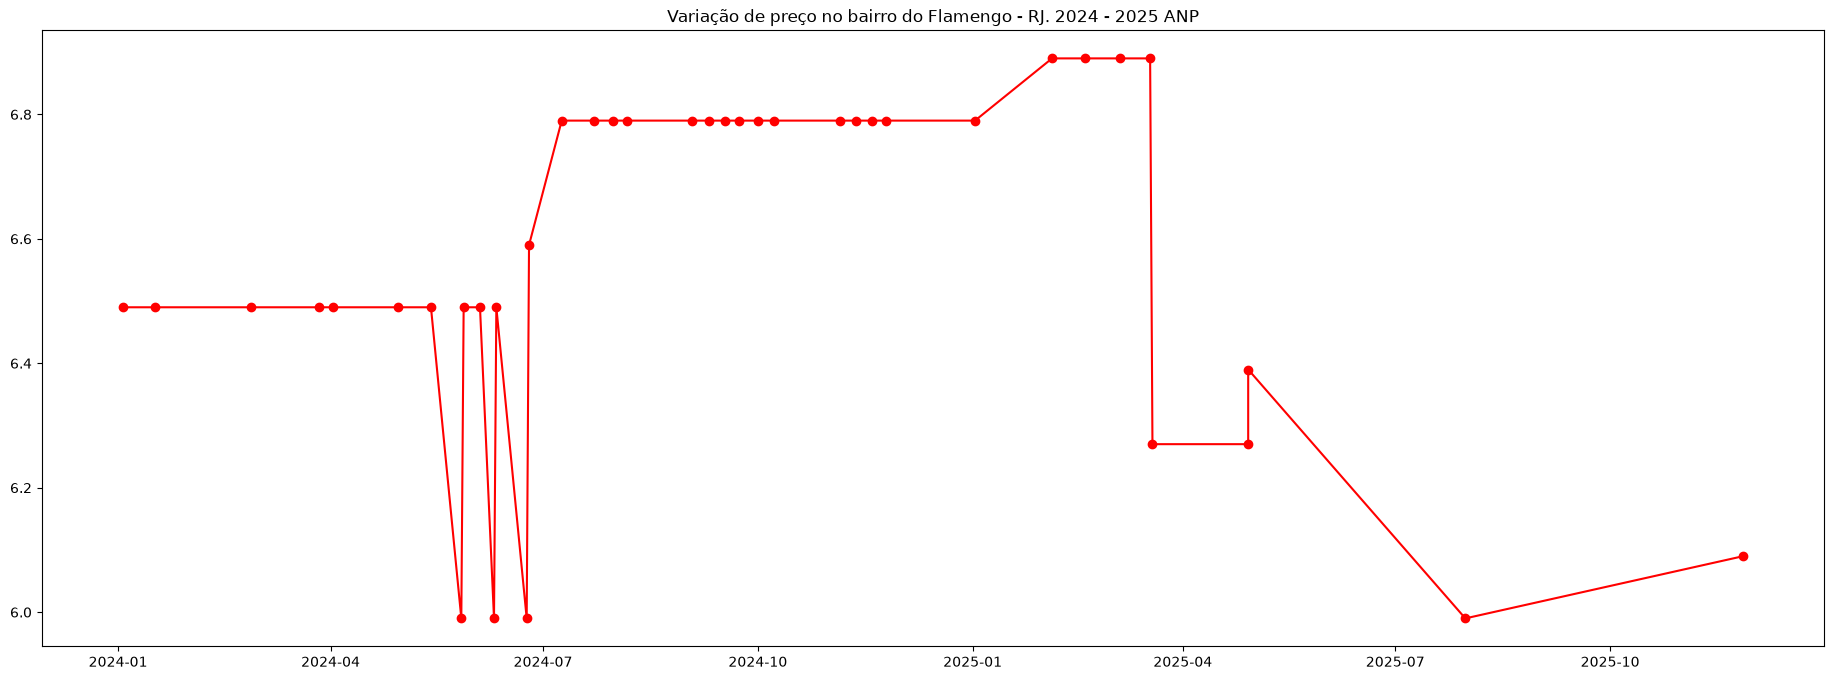

In [61]:
plt.figure(figsize=(23,8))
plt.plot(df_gasosa_fla['Data da Coleta'], df_gasosa_fla['Valor de Venda'], marker = 'o', color='red')
plt.title('Variação de preço no bairro do Flamengo - RJ. 2024 - 2025 ANP')
plt.show